# Comparison of Radial Profiles: IO vs NIO vs Observations

Comparing: NGC2403, NGC2841, UGC05721

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
IO_DIR = BASE_DIR / "outputs" / "model_radial_profiles" / "io"
NIO_DIR = BASE_DIR / "outputs" / "model_radial_profiles" / "nio"
HI_DIR = BASE_DIR / "data" / "allHIprofs_mod"
SFR_DIR = BASE_DIR / "data" / "allSFRprofs"
STARS_DIR = BASE_DIR / "data" / "allSTARSprofs"

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

In [2]:
def load_model_profile(filepath):
    data = np.load(filepath, allow_pickle=True)
    return {key: data[key] for key in data.files}

def load_observed_HI(galaxy_name):
    filepath = HI_DIR / f"{galaxy_name}_fullHI.dat"
    if not filepath.exists(): return None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 2]

def load_observed_SFR(galaxy_name):
    filepath = SFR_DIR / f"{galaxy_name}_R_Vrot_SigmaGas_SigmaSFR.txt"
    if not filepath.exists(): return None, None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 3]/1e6, data[:, 5]*1e9/1e6

def load_observed_stars(galaxy_name):
    filepath = STARS_DIR / f"{galaxy_name}_fullstars.dat"
    if not filepath.exists(): return None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 3]

def get_profile_at_t0(profile, key):
    arr = profile[key]
    return arr[:, -1] if arr.ndim == 2 else arr

In [3]:
GALAXIES = ["NGC2403", "NGC2841", "DDO50"]
profiles = {}

for gal in GALAXIES:
    profiles[gal] = {"io": None, "nio": None, "obs_HI": None, "obs_SFR": None, "obs_stars": None}
    
    io_file = IO_DIR / f"{gal}_profile.npz"
    if io_file.exists():
        profiles[gal]["io"] = load_model_profile(io_file)
        print(f"{gal}: Loaded IO model")
    
    nio_file = NIO_DIR / f"{gal}_profile.npz"
    if nio_file.exists():
        profiles[gal]["nio"] = load_model_profile(nio_file)
        print(f"{gal}: Loaded NIO model")
    
    r_hi, sigma_hi = load_observed_HI(gal)
    if r_hi is not None:
        profiles[gal]["obs_HI"] = {"r_kpc": r_hi, "Sigma_HI": sigma_hi}
    
    r_sfr, sigma_gas_sfr, sigma_sfr = load_observed_SFR(gal)
    if r_sfr is not None:
        profiles[gal]["obs_SFR"] = {"r_kpc": r_sfr, "Sigma_gas": sigma_gas_sfr, "Sigma_SFR": sigma_sfr}
    
    r_star, sigma_star = load_observed_stars(gal)
    if r_star is not None:
        profiles[gal]["obs_stars"] = {"r_kpc": r_star, "Sigma_star": sigma_star}
    print()

NGC2403: Loaded IO model
NGC2403: Loaded NIO model

NGC2841: Loaded IO model
NGC2841: Loaded NIO model

DDO50: Loaded IO model
DDO50: Loaded NIO model



In [15]:
def plot_galaxy_comparison(gal, p, x_max=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'{gal} - Model vs Observed', fontsize=16, fontweight='bold')

    io, nio = p['io'], p['nio']
    obs_hi, obs_sfr, obs_stars = p['obs_HI'], p['obs_SFR'], p['obs_stars']

    # Auto-determine x_max if not provided: find where gas density drops below threshold
    if x_max is None and io is not None:
        r_kpc = io['r_kpc']
        final_gas = get_profile_at_t0(io, 'Sigma_gas')
        valid_idx = np.where(final_gas > 1e-2)[0]
        x_max = r_kpc[valid_idx[-1]] * 1.1 if len(valid_idx) > 0 else 30
    elif x_max is None:
        x_max = 30

    # Gas
    ax = axes[0, 0]
    ax.set_title(r'Gas Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\rm gas}$ (M$_\odot$ / pc$^2$)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_gas'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_gas' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_gas'), '--', color='C1', label='NIO', lw=2)
    if obs_hi:
        ax.scatter(obs_hi['r_kpc'], 1.4*obs_hi['Sigma_HI'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-2, 1e3)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Stars
    ax = axes[0, 1]
    ax.set_title('Stellar Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\star}$ (M$_\odot$ / pc$^2$)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_star'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_star' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_star'), '--', color='C1', label='NIO', lw=2)
    if obs_stars:
        ax.scatter(obs_stars['r_kpc'], obs_stars['Sigma_star'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-3, 1e4)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # SFR
    ax = axes[1, 0]
    ax.set_title('SFR Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\rm sfr}$ (M$_\odot$ / pc$^2$/Gyr)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_sfr'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_sfr' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_sfr'), '--', color='C1', label='NIO', lw=2)
    if obs_sfr and obs_sfr['Sigma_SFR'] is not None:
        ax.scatter(obs_sfr['r_kpc'], obs_sfr['Sigma_SFR'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-6, 1e2)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # SFH
    ax = axes[1, 1]
    ax.set_title('Star Formation History')
    ax.set_xlabel('Time (Gyr)')
    ax.set_ylabel(r'SFR (M$_\odot$ / Gyr)')
    ax.set_yscale('log')
    if io and 'SFH' in io:
        ax.plot(io['times'], io['SFH'], '-', color='C0', label='IO', lw=2)
    if nio and 'SFH' in nio:
        ax.plot(nio['times'], nio['SFH'], '--', color='C1', label='NIO', lw=2)
    ax.set_xlim(0, 12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if io:
        fig.text(0.5, 0.03, rf"IO: ${{\log M_{{\rm bar}}}}={float(io.get('log_M_bar',0)):.2f}, t_{{\rm acc}}={float(io.get('t_acc',0)):.2f}$ Gyr", ha='center', fontsize=11)
    if nio:
        fig.text(0.5, 0.01, rf"NIO: ${{\log M_{{\rm bar}}}}={float(nio.get('log_M_bar',0)):.2f}, t_{{\rm acc}}={float(nio.get('t_acc',0)):.2f}$ Gyr", ha='center', fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

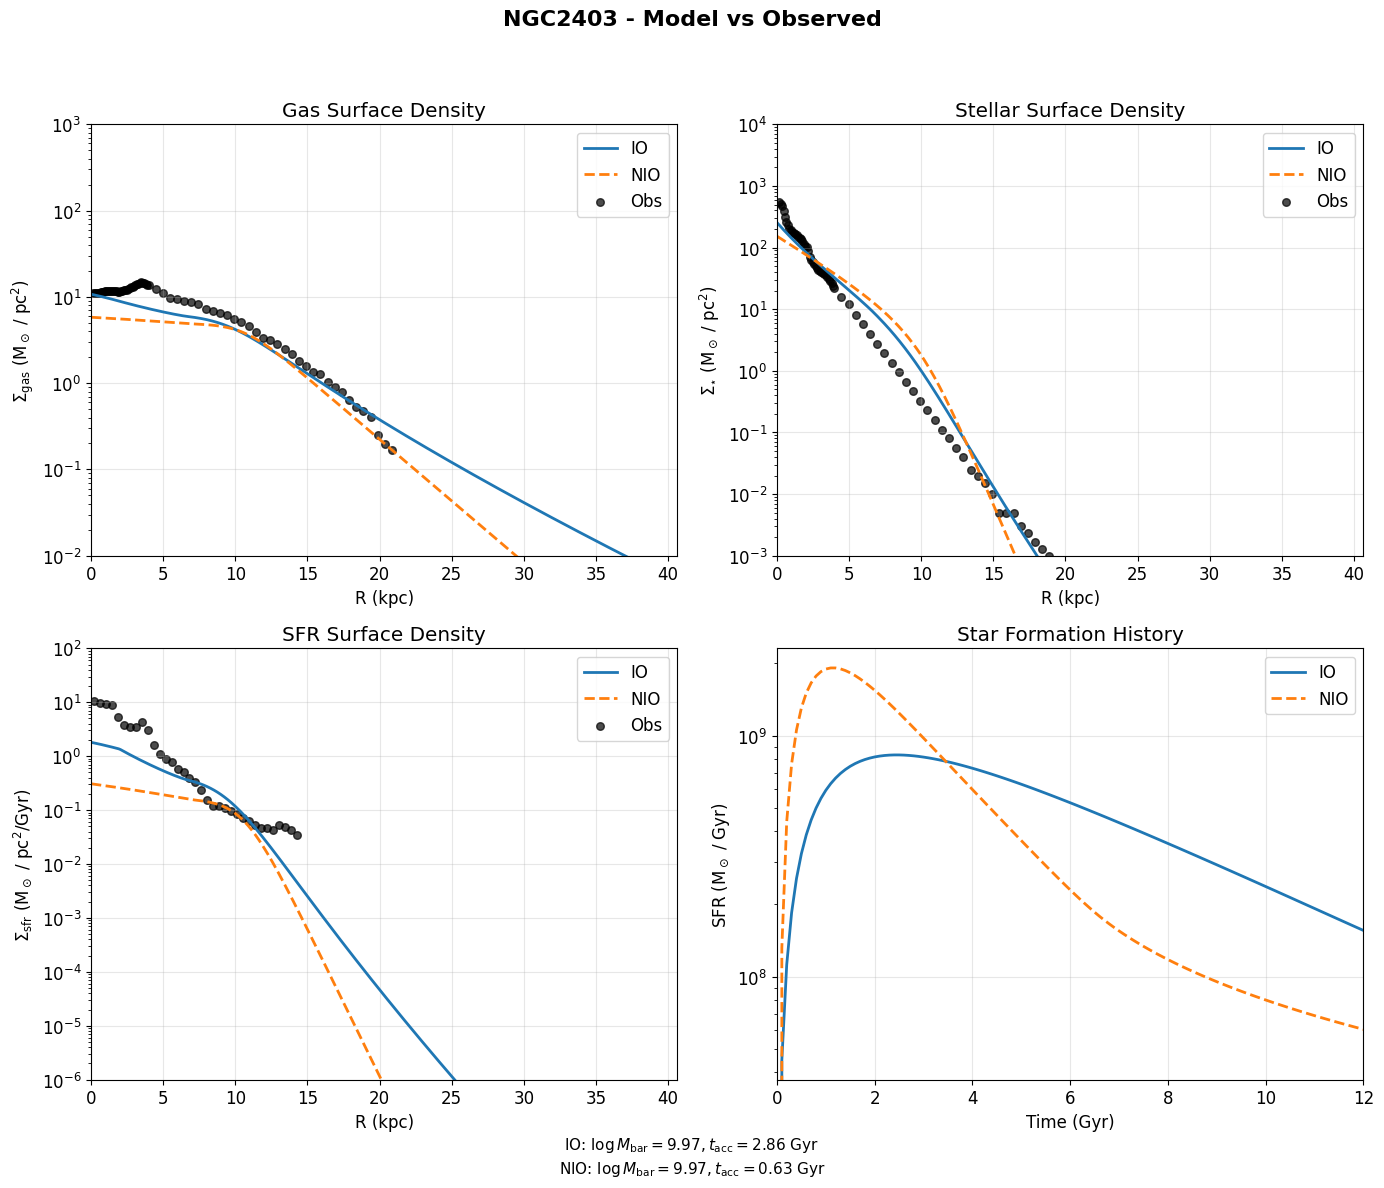

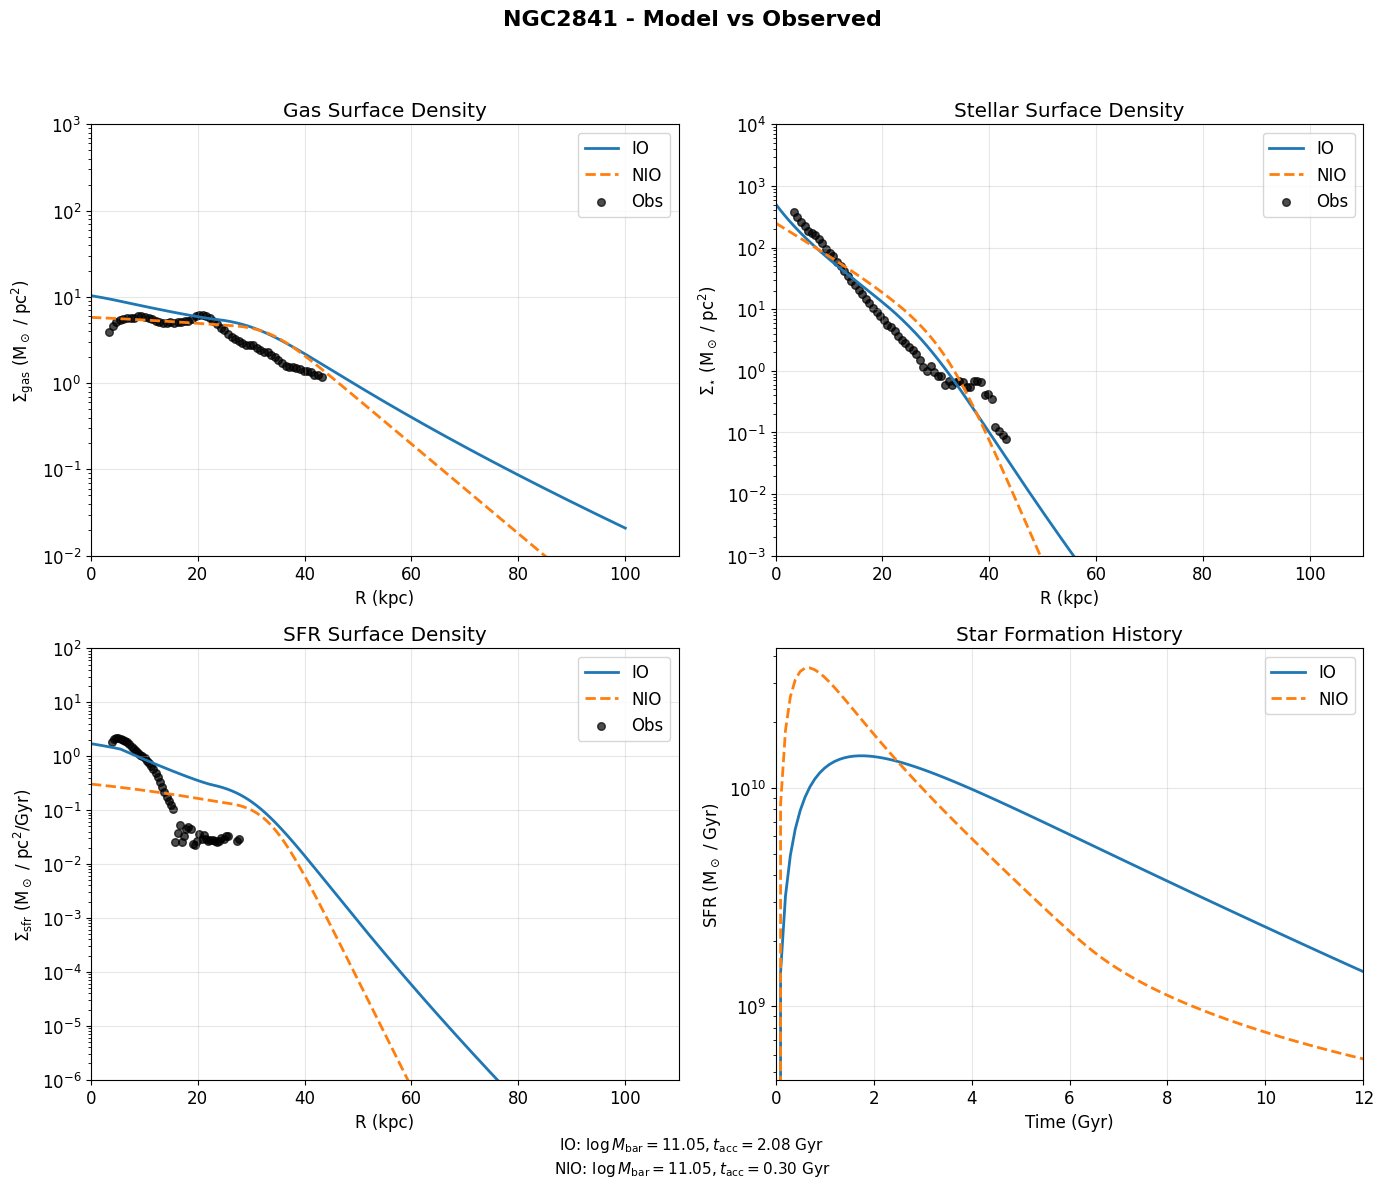

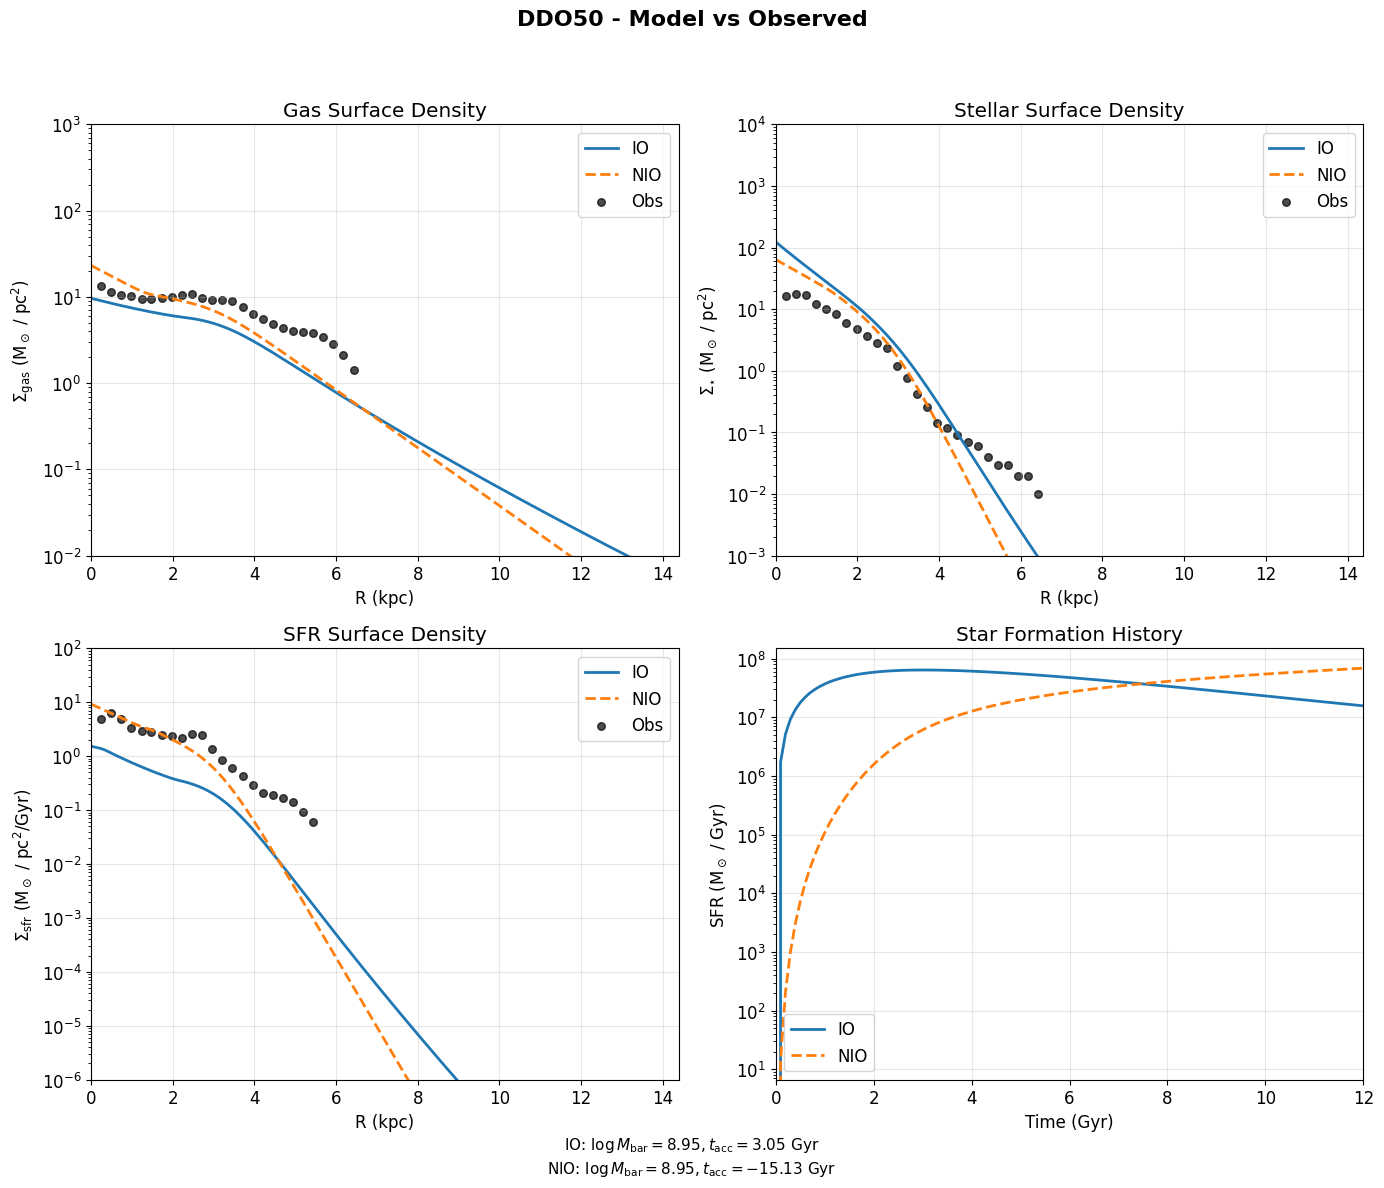

In [16]:
output_dir = BASE_DIR / "outputs" / "radial_profile_comparisons"
output_dir.mkdir(exist_ok=True, parents=True)

for gal in GALAXIES:
    fig = plot_galaxy_comparison(gal, profiles[gal])
    fig.savefig(output_dir / f"{gal}_profile_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## Time Evolution

In [6]:
def plot_time_evolution(gal, p, times_to_plot=[3, 6, 9, 12], x_max=None, model_type="io"):
    io = p["io"]
    nio = p.get("nio", None)
    if io is None and nio is None: return None

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
    fig.suptitle(f"{gal} - Time Evolution ({model_type.upper()})", fontsize=14, fontweight="bold")

    r_kpc, times = io["r_kpc"], io["times"]
    cmap = plt.cm.viridis

    for t_target in times_to_plot:
        t_idx = np.argmin(np.abs(times - t_target))
        color = cmap(t_target / 12.0)
        if model_type == "io":
            axes[0].plot(r_kpc, io["Sigma_gas"][:, t_idx], color=color, label=f"t={times[t_idx]:.1f}")
            axes[1].plot(r_kpc, io["Sigma_star"][:, t_idx], color=color)
            axes[2].plot(r_kpc, io["Sigma_sfr"][:, t_idx], color=color)
        elif model_type == "nio":
            axes[0].plot(r_kpc, nio["Sigma_gas"][:, t_idx], color=color, label=f"t={times[t_idx]:.1f}")
            axes[1].plot(r_kpc, nio["Sigma_star"][:, t_idx], color=color)
            axes[2].plot(r_kpc, nio["Sigma_sfr"][:, t_idx], color=color)
        else:
            raise ValueError("model_type must be 'io' or 'nio'")

    # Auto-determine x_max if not provided: find where gas density drops below threshold
    if x_max is None:
        final_gas = io["Sigma_gas"][:, -1]
        valid_idx = np.where(final_gas > 1e-2)[0]
        x_max = r_kpc[valid_idx[-1]] * 1.1 if len(valid_idx) > 0 else r_kpc[-1]

    for i, (ax, title, ylim) in enumerate(zip(axes, [r"$\Sigma_{\rm gas}$", r"$\Sigma_{\star}$", r"$\Sigma_{\rm sfr}$"], [(1e-2, 1e3), (1e-3, 1e4), (1e-6, 1e2)])):
        ax.set_xlabel("R (kpc)")
        ax.set_yscale("log")
        ax.set_xlim(0, x_max)
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    return fig

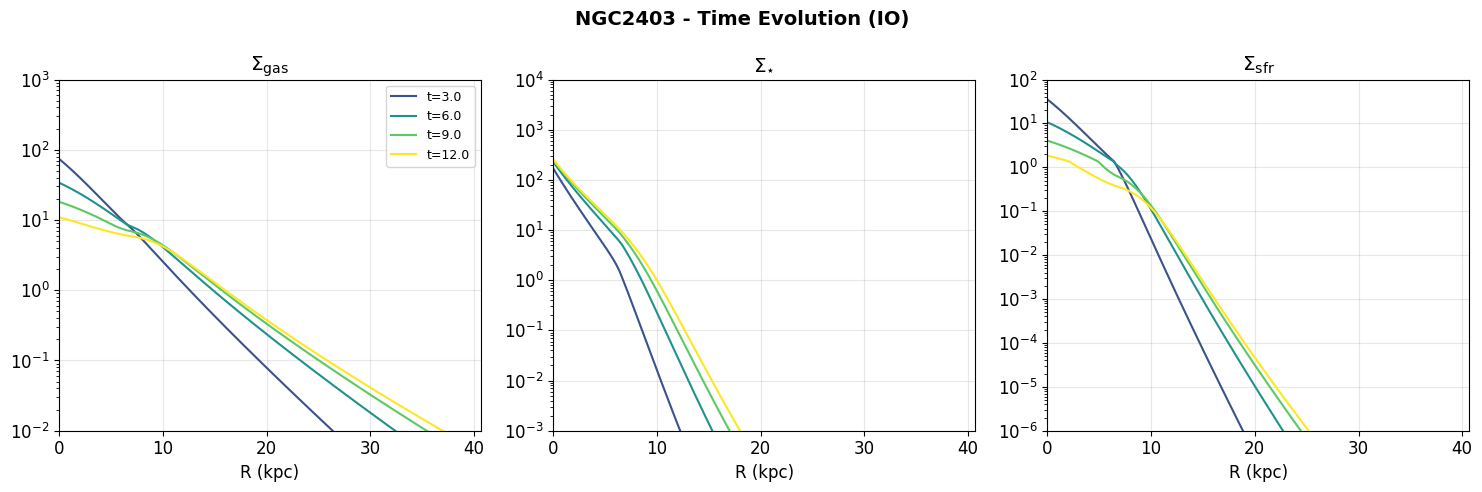

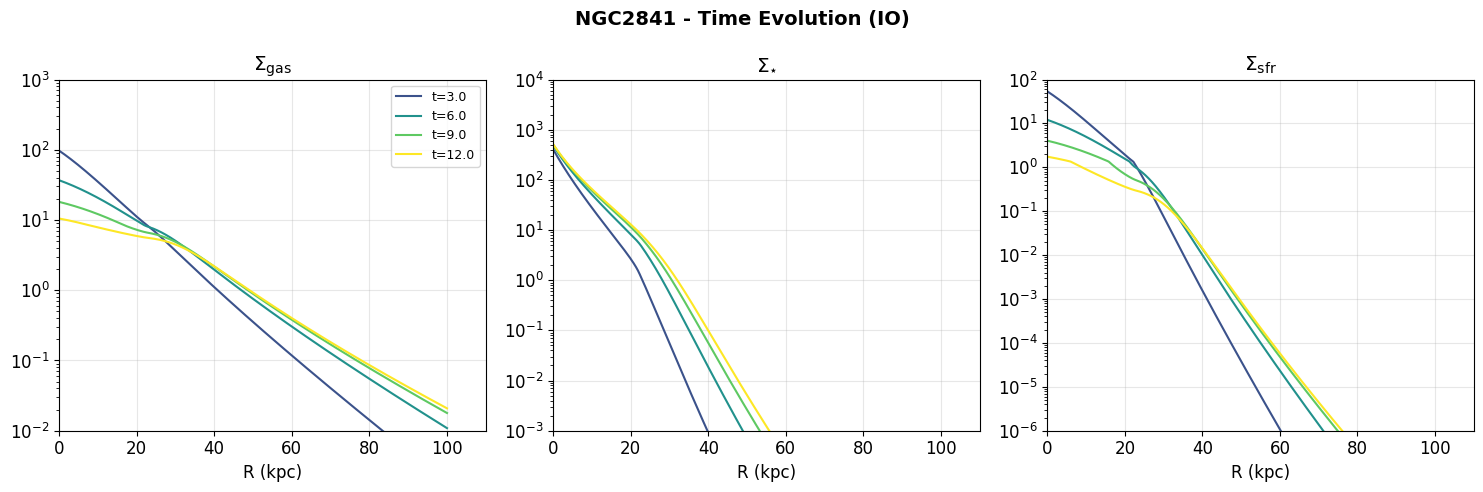

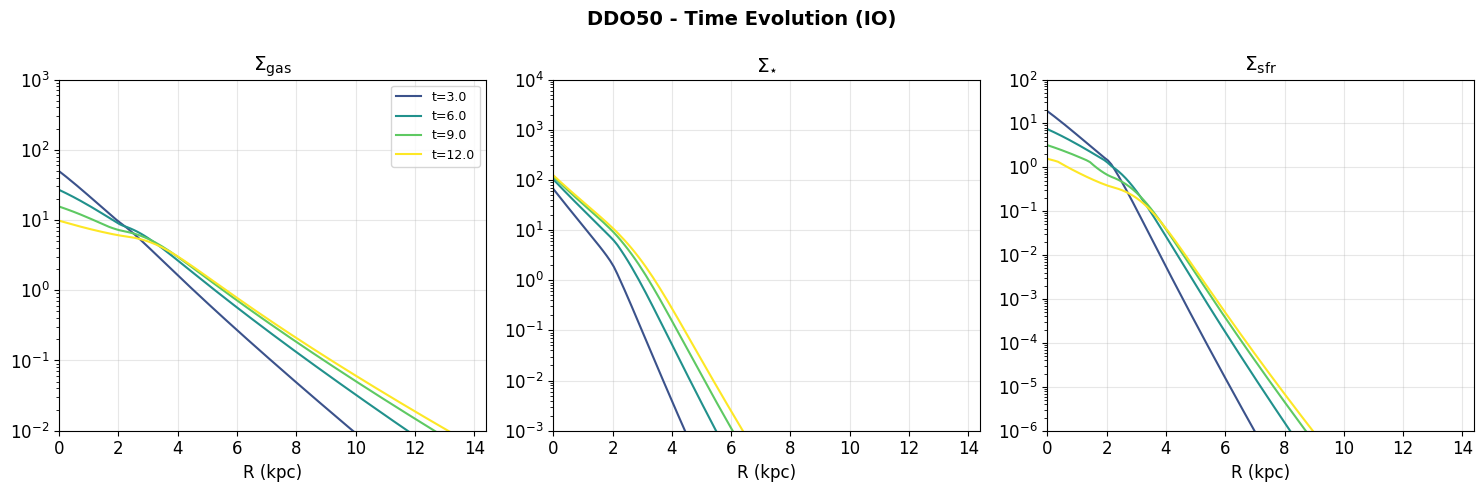

In [7]:
for gal in GALAXIES:
    fig = plot_time_evolution(gal, profiles[gal], model_type="io")
    if fig:
        fig.savefig(output_dir / f"{gal}_time_evolution_io.png", dpi=150, bbox_inches="tight")
        plt.show()

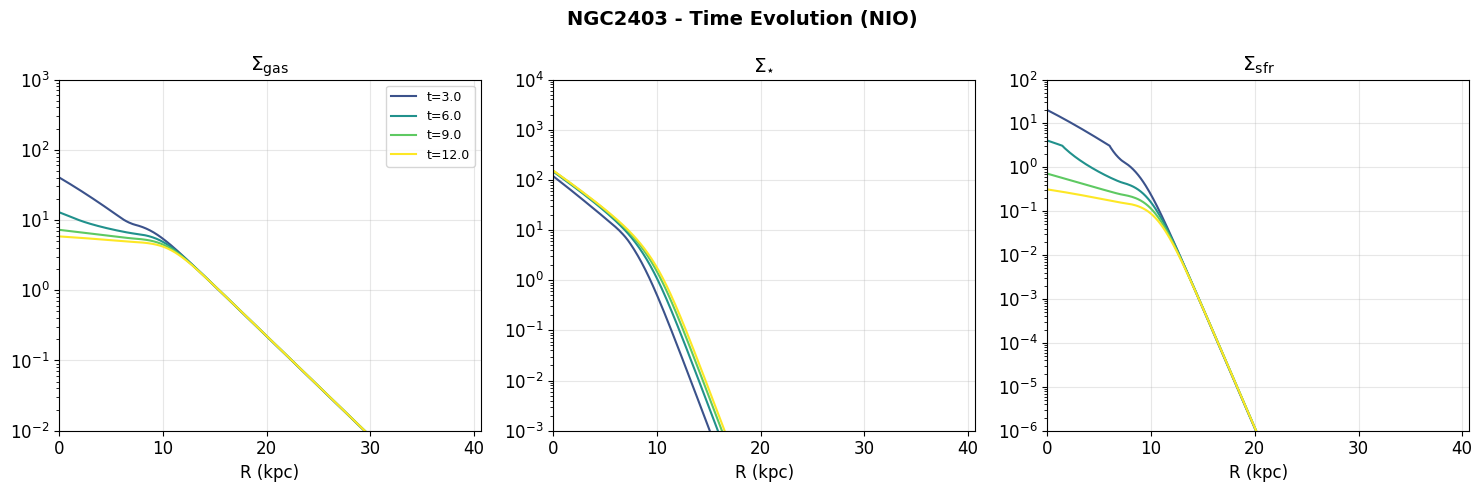

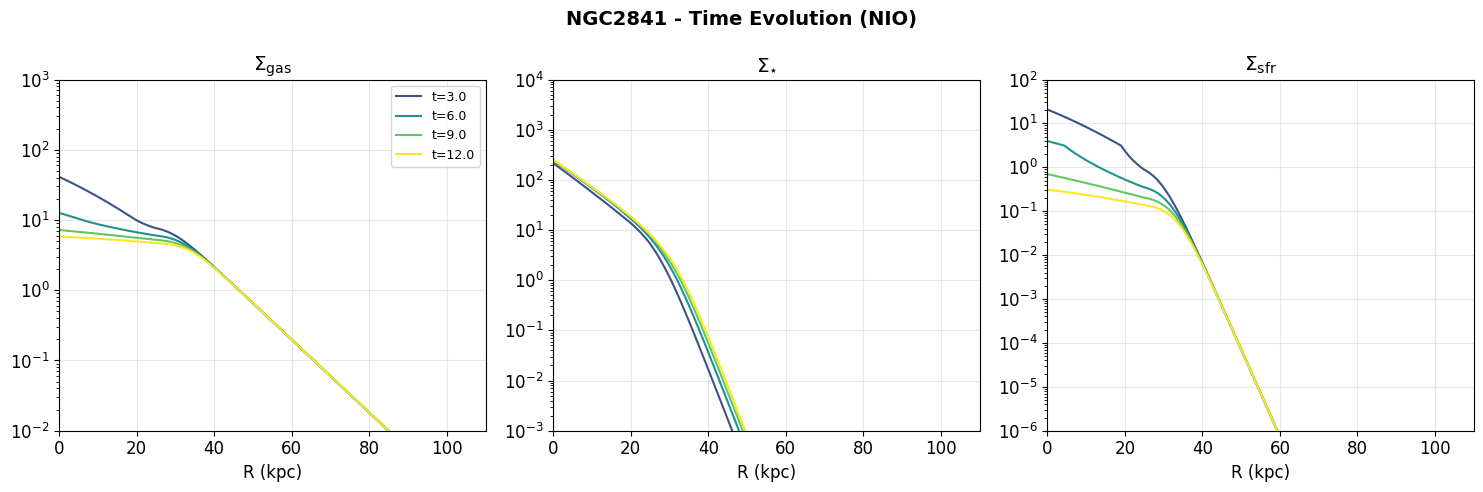

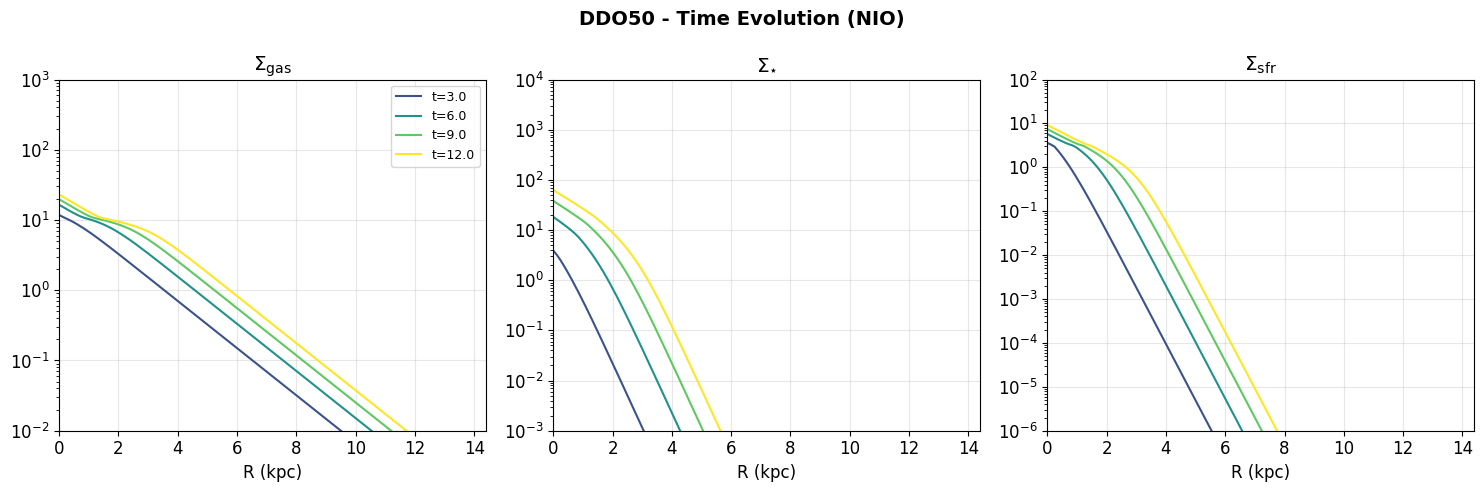

In [8]:
for gal in GALAXIES:
    fig = plot_time_evolution(gal, profiles[gal], model_type="nio")
    if fig:
        fig.savefig(output_dir / f"{gal}_time_evolution_nio.png", dpi=150, bbox_inches="tight")
        plt.show()